In [27]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot

file_path = pq.ParquetFile('../data/lectures_horaries_ABD.parquet')

table = file_path.read()
df = table.to_pandas()

In [28]:
#constants
POLICY = 'Pòlissa/Póliza/Policy'
TECHNOLOGY = 'Tecnologia/Tecnología/Technology'
DIAMETER = 'Diàmetre comptador (cm)/Diámetro contador (cm)/Counter diameter (cm)'
USAGE = 'Ús/Uso/Use'
HOUSING = "Tipus d'habitatge/Tipo de vivienda/Type of housing"
DATE = 'Data/Fecha/Date'
CONSUMPTION = 'Índex de lectura (L/h)/Índice de lectura (L/h)/Reading index (L/h)'

In [3]:
print(df.head())  # First 5 rows

                               Pòlissa/Póliza/Policy  \
0  9a588b6ba55d2c7baed4c039328f3bfb3fbab2c78dbe30...   
1  9a588b6ba55d2c7baed4c039328f3bfb3fbab2c78dbe30...   
2  9a588b6ba55d2c7baed4c039328f3bfb3fbab2c78dbe30...   
3  9a588b6ba55d2c7baed4c039328f3bfb3fbab2c78dbe30...   
4  9a588b6ba55d2c7baed4c039328f3bfb3fbab2c78dbe30...   

  Tecnologia/Tecnología/Technology  \
0                                R   
1                                R   
2                                R   
3                                R   
4                                R   

   Diàmetre comptador (cm)/Diámetro contador (cm)/Counter diameter (cm)  \
0                                               15.0                      
1                                               15.0                      
2                                               15.0                      
3                                               15.0                      
4                                               15.0       

In [4]:
print(df.columns) # Column names

Index(['Pòlissa/Póliza/Policy', 'Tecnologia/Tecnología/Technology',
       'Diàmetre comptador (cm)/Diámetro contador (cm)/Counter diameter (cm)',
       'Ús/Uso/Use', 'Tipus d'habitatge/Tipo de vivienda/Type of housing',
       'Data/Fecha/Date',
       'Índex de lectura (L/h)/Índice de lectura (L/h)/Reading index (L/h)'],
      dtype='object')


In [5]:
print(df.info())  # Data types and missing values 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48806647 entries, 0 to 48806646
Data columns (total 7 columns):
 #   Column                                                                Dtype  
---  ------                                                                -----  
 0   Pòlissa/Póliza/Policy                                                 object 
 1   Tecnologia/Tecnología/Technology                                      object 
 2   Diàmetre comptador (cm)/Diámetro contador (cm)/Counter diameter (cm)  float64
 3   Ús/Uso/Use                                                            object 
 4   Tipus d'habitatge/Tipo de vivienda/Type of housing                    object 
 5   Data/Fecha/Date                                                       object 
 6   Índex de lectura (L/h)/Índice de lectura (L/h)/Reading index (L/h)    float64
dtypes: float64(2), object(5)
memory usage: 2.5+ GB
None


In [6]:
waterFlow = df[CONSUMPTION] # Flow of the water

In [7]:
waterFlowGradient = np.gradient(waterFlow, axis=0)

In [8]:
np.histogram(waterFlowGradient, bins=9)

(array([       2,        2,        2,        6, 48806593,       32,
               6,        2,        2]),
 array([-44143413.5       , -34918282.22222222, -25693150.94444444,
        -16468019.66666666,  -7242888.38888889,   1982242.88888889,
         11207374.16666667,  20432505.44444445,  29657636.72222222,
         38882768.        ]))

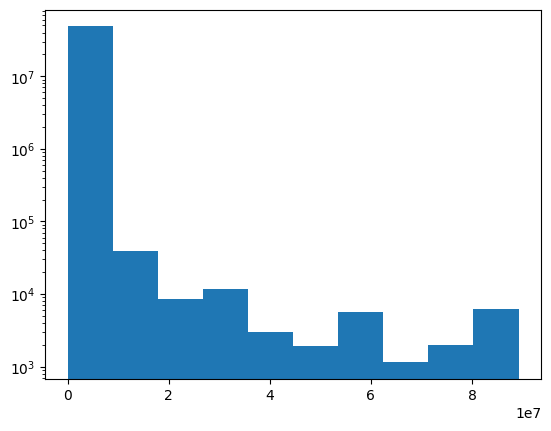

In [9]:
plot.hist(waterFlow)
plot.yscale('log')
plot.show()

In [10]:
np.max(waterFlowGradient)

np.float64(38882768.0)

In [11]:
np.min(waterFlowGradient)

np.float64(-44143413.5)

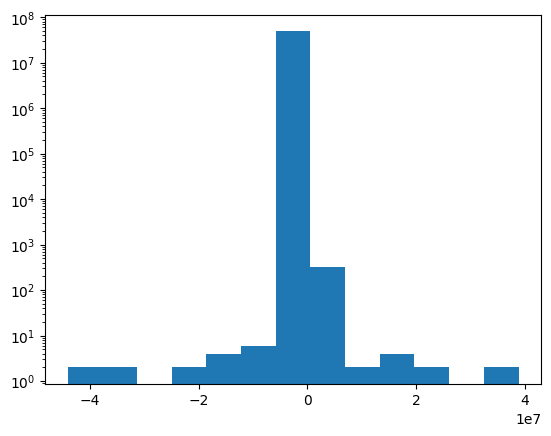

In [12]:
plot.hist(waterFlowGradient, bins=13)
plot.yscale('log')
plot.show()

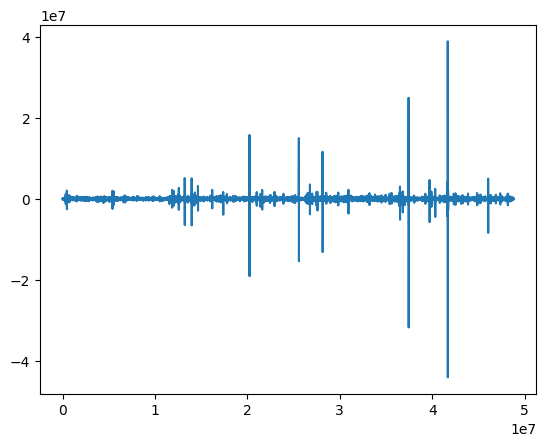

In [13]:
plot.plot(waterFlowGradient)
plot.show()

In [14]:
waterFlowDiff = np.diff(waterFlow, 1, 0)

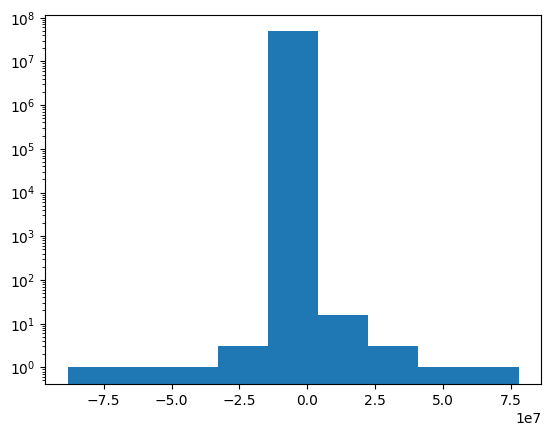

In [15]:
plot.hist(waterFlowDiff, bins=9)
plot.yscale('log')
plot.show()

In [16]:
np.mean(waterFlow) # Mean of the flow of the water 

np.float64(520085.57774812926)

In [17]:
np.median(waterFlow) # Median of the flow of the water

np.float64(374700.0)

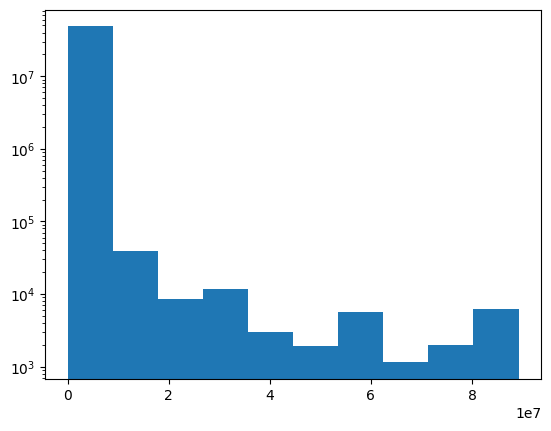

In [18]:
# Plot of the flow of water to see the distribution better
plot.hist(waterFlow)
plot.yscale('log')
plot.show()

In [19]:
#variables to study and plot

# Policies
policies = df[POLICY].unique()
policiesNumber = df[POLICY].nunique()
waterFlowPolicies = df[[POLICY, CONSUMPTION]].groupby([POLICY]).sum()[CONSUMPTION].to_numpy()

In [20]:
# Tech types
techTypes = df[TECHNOLOGY].unique()
waterFlowTech = df[[TECHNOLOGY, CONSUMPTION]].groupby([TECHNOLOGY]).sum()[CONSUMPTION].to_numpy()

In [21]:
# Diameters
diameters = df[DIAMETER].unique()
waterFlowDiameter = df[[DIAMETER, CONSUMPTION]].groupby([DIAMETER]).sum()[CONSUMPTION].to_numpy()

In [22]:
# Use
use = df[USAGE].unique()
useNumber = df[USAGE].nunique()
waterFlowUse = df[[USAGE, CONSUMPTION]].groupby([USAGE]).sum()[CONSUMPTION].to_numpy()

In [23]:
# Housing
housing = df[HOUSING].unique()
housingNumber = df[HOUSING].nunique()
waterFlowHousing = df[[HOUSING, CONSUMPTION]].groupby([HOUSING]).sum()[CONSUMPTION].to_numpy()

In [29]:
# This is one year, somehow 151 hours are missing
test = df[CONSUMPTION][0:len(df[DATE].unique())-151]

In [ ]:
# Date
df[DATE] = df[DATE].str.split(':', n=1, expand=True)[0:][0].str.split(' ', n=1, expand=True)[1]
date = df[DATE].unique()
dateNumber = len(date)

In [ ]:
waterFlowDateMedian = df[[DATE, CONSUMPTION]].groupby([DATE]).mean()[CONSUMPTION]
waterFlowDateMedianGradient = np.gradient(waterFlowDateMedian, axis=0)

waterFlowDateSum = df[[DATE, CONSUMPTION]].groupby([DATE]).sum()[CONSUMPTION]
waterFlowDateSumGradient = np.gradient(waterFlowDateSum, axis=0)

In [ ]:
plot.hist(np.gradient(test, axis=0), bins=122)
plot.yscale('log')
plot.show()

In [ ]:
plot.plot(test)
plot.show()

In [ ]:
df[CONSUMPTION][0:72]

In [ ]:
# lol, found one by accident
plot.plot(np.diff(df[CONSUMPTION][0:72]))
plot.show()

In [30]:
np.histogram(np.gradient(test, axis=0), bins=122)

(array([      2,       0,       2,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       0,       0,       0,       0,       0,       0,
              0,       2,       0,       0,       0,       0,       0,
              2,       0,       0,       0,       0,       2,       0,
              0,       0,       2,       0,       2,       4,       2,
              4,       4,      12,       2,      14,      12,      12,
              8,      14,      20,      28,      32,      48,      44,
             52,      64,      90,     100,     142,     144, 6025612,
             94,     108,      64,      82,      36,      40,      44,
             18,      20,      20,       8,       4,       6,       6,
              4,       4,       0,       2,       0,       2,       0,
              0,       2,       2,       0,       0,       0,       2,
      

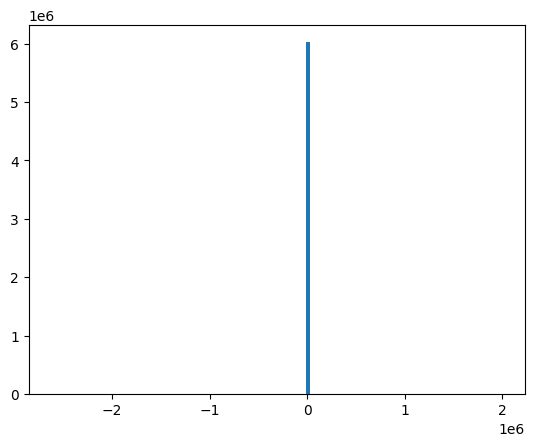

In [35]:
plot.hist(np.gradient(test, axis=0), bins=122)
plot.show()

In [ ]:
# Covariance (and correlation) of the flow of water and policy
np.cov(range(policiesNumber), waterFlowPolicies)

In [ ]:
# Plot of the relation between policy and flow of water
plot.plot(waterFlowPolicies)
plot.show()

#showPlot(df['Pòlissa/Póliza/Policy'], df['Índex de lectura (L/h)/Índice de lectura (L/h)/Reading index (L/h)'], 0)

In [ ]:
# Covariance (and correlation) between the technology and the flow of water
t1 = np.array([], dtype = int)
for i in range(len(techTypes)):
    t1 = np.append(t1, ord(techTypes[i]))
np.cov(t1, waterFlowTech)

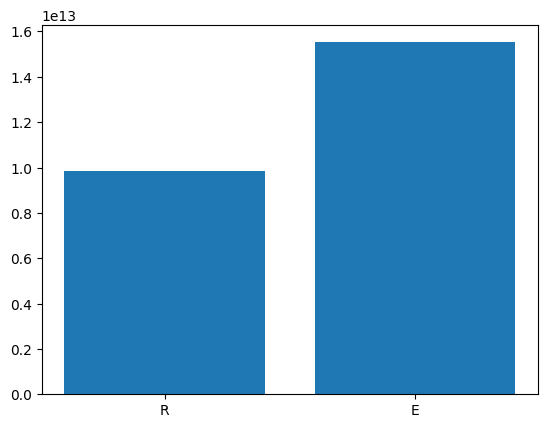

In [34]:
# Plot to visualize the relationship between technology and flow of water
plot.bar(techTypes, waterFlowTech)
plot.show()

In [ ]:
# Covariance (and correlation) of the flow of water and the counter diameter
np.cov(diameters, waterFlowDiameter)

In [ ]:
# Plot to visualize the relation between the counter diameter and the flow of water
plot.bar(diameters, waterFlowDiameter)
plot.yscale('log')
plot.show()

In [ ]:
# Covariance (and correlation) of the flow of water and the counter diameter
np.cov(range(useNumber), waterFlowUse)

In [ ]:
# Plot of the flow of water and use type
plot.bar(use, waterFlowUse)
plot.show()

In [ ]:
plot.hist(df[USAGE])
plot.show()

In [ ]:
# Covariance (and correlation) of the flow of water and the counter diameter
np.cov(range(housingNumber), waterFlowHousing)

In [ ]:
# Logarithmic plot of the correlation between the type of housing and flow of water to see a correlation
plot.bar(housing, waterFlowHousing)
plot.yscale('log')
plot.show()

In [ ]:
dataDateSumC = df[[DATE, CONSUMPTION, USAGE]][df[USAGE] == 'COMERCIAL'].groupby(DATE)[CONSUMPTION].sum().to_numpy()
dataDateSumD = df[[DATE, CONSUMPTION, USAGE]][df[USAGE] == 'DOMESTIC'].groupby(DATE)[CONSUMPTION].sum().to_numpy()
dataDateSumI = df[[DATE, CONSUMPTION, USAGE]][df[USAGE] == 'INDUSTRIAL'].groupby(DATE)[CONSUMPTION].sum().to_numpy()
dataDateSumA = df[[DATE, CONSUMPTION, USAGE]][df[USAGE] == 'AJUNTAMENT'].groupby(DATE)[CONSUMPTION].sum().to_numpy()

In [ ]:
amountUsages = df[USAGE].value_counts(sort=False)

In [ ]:
amountUsages

In [ ]:
plot.plot(dataDateSumC/amountUsages[0])
plot.show()

In [ ]:
dataDateSumC/amountUsages[0]

In [ ]:
plot.plot(dataDateSumD/amountUsages[1])
plot.show()

In [ ]:
plot.plot(dataDateSumI/amountUsages[2])
plot.show()

In [ ]:
plot.plot(dataDateSumA/amountUsages[3])
plot.show()

In [ ]:
plot.hist(dataDateSumC, bins=17)
plot.show()

In [ ]:
np.histogram(dataDateSumC/amountUsages[0], 17)

In [ ]:
plot.hist(dataDateSumD)
plot.show()

In [ ]:
np.histogram(dataDateSumD/amountUsages[1])

In [ ]:
plot.hist(dataDateSumI)
plot.show()

In [ ]:
np.histogram(dataDateSumI/amountUsages[2])

In [ ]:
plot.hist(dataDateSumA)
plot.show()

In [ ]:
np.histogram(dataDateSumA/amountUsages[3])

In [ ]:
# Plot to see the relation between the date and flow of water
plot.hist(waterFlowDateSum, bins=122)
plot.yscale('log')
plot.show()

In [ ]:
np.histogram(waterFlowDateSum, bins=122)

In [ ]:
waterFlowUse

In [ ]:
df[USAGE].value_counts(sort=False)

In [ ]:
waterFlowUse/df[USAGE].value_counts(sort=False)

In [ ]:
# Plot to see the relation between the date and flow of water
plot.hist(waterFlowDateMedianGradient, bins=9)
plot.yscale('log')
plot.show()

In [ ]:
# Plot to see the relation between the date and flow of water
plot.hist(waterFlowDateSumGradient, bins=9)
plot.yscale('log')
plot.show()

In [ ]:
waterFlowDateSum.sum()

In [ ]:
df[CONSUMPTION].sum()

In [ ]:
# Plot to see the relation between the date and flow of water
plot.hist(np.diff(waterFlowDateMedian, 1, 0), bins=13)
plot.yscale('log')
plot.show()

In [ ]:
np.histogram(waterFlowDateMedianGradient, bins=30)

In [ ]:
# Plot to see the evolution of water flow gradient over time
plot.plot(waterFlowDateMedian)
plot.show()